In [1]:
using Piccolo
using CairoMakie

In [2]:
using QuantumToolbox
using DifferentialEquations

## Defining Rho dot

In [3]:
σ_ = ComplexF64[0 1; 0 0]
σz = ComplexF64[1 0; 0 -1]

function Commutator(H, ρ)
    return H * ρ - ρ * H
end

function Anti_Commutator(H, ρ)
    return H * ρ + ρ * H
end

function inner_D(ρ, σ)
    return σ * ρ * σ' - 0.5 * Anti_Commutator(σ' * σ, ρ)
end

function D_1(ρ, T1::Real, σ)
    return 1/T1 * inner_D(ρ, σ)
end

function D_ϕ(ρ, Tϕ::Real, σ)
    return 1/(2* Tϕ) * inner_D(ρ, σ)
end

# function ρ̇!1(H, ρ)
#     return (- im * Commutator(H, ρ) + D_1(ρ, T1, σ_) + D_ϕ(ρ, Tϕ, σz))
# end

# function Hamiltonian(t, Tg; N = 100)
#     H0 = ComplexF64[0 0; 0 0]
    
#     function gaussian_curve(t, Tg, N)
#         Ω0 = π / (Tg * (super_duper_value - ℯ^(-2))) / 2
#         μ = Tg / 2
#         σ = Tg / 4
#         return Ω0 * (ℯ .^ (-(t .- μ) .^2 / (2σ^2)) .- ℯ .^ (-2))
#     end

#     return  H0 .+ gaussian_curve(t, Tg, N) .* σx / 2
# end

D_ϕ (generic function with 1 method)

In [4]:
σ_ = ComplexF64[0 1; 0 0]
σx = ComplexF64[0 1; 1 0] 
σz = ComplexF64[1 0; 0 -1]

const super_duper_value = 0.598144006661 # integral from -1/2 to 1/2 of e^(-8u^2)

function gaussian_curve(t, Tg, N)
    Ω0 = π / (Tg * (super_duper_value - ℯ^(-2))) / 2
    μ = Tg / 2
    σ = Tg / 4
    return Ω0 * (ℯ .^ (-(t .- μ) .^2 / (2σ^2)) .- ℯ .^ (-2))
end

function Hamiltonian(t, Tg; N = 100)
    H0 = ComplexF64[0 0; 0 0]
    return  H0 .+ gaussian_curve(t, Tg, N) .* σx # / 2
end

function ρ̇!(drho, rho, p, t)
    H = Hamiltonian(t, Tg)
    drho .= (- im * Commutator(H, rho) + D_1(rho, T1, σ_) + D_ϕ(rho, Tϕ, σz))
end

ρ̇! (generic function with 1 method)

## Main code base(Small scale)

In [47]:
T1 = 150 * 10
Tϕ = 100 * 10
initial_state = ComplexF64[1; 0]
ρ0 = initial_state * initial_state'
Tg = 10

function calc_infidelity(states)
    infidelity = []
    for i in range(1, size(states)[1])
        push!(infidelity, 1 .- real(Uhlmann_Fidelity(target_ρ, states[i])))
        end
    return infidelity
end

function calc_population(states)
    populations = []
    for i in range(1, size(states)[1])
        push!(populations, real(initial_state' * states[i] * initial_state))
        end
    return populations
end

function solving(time, chooser)
    t_span = (0.0, time)
    prob = ODEProblem(ρ̇!, ρ0,adaptive=false, t_span)
    sol = solve(prob, Tsit5(), dt = 0.1)
    states = sol.u
    if chooser == 0
        return states
    elseif chooser == 1
        calc_population(states)
    elseif chooser == 2 
        calc_infidelity(states)
    end
end

function result(time)
    t_span = (0.0, time)
    prob = ODEProblem(ρ̇!, ρ0,adaptive=false, t_span)
    sol = solve(prob, Tsit5(), dt = 0.1)
    return sol
end

function Uhlmann_Fidelity(ρ_target, ρ_final)
    real((tr(sqrt(sqrt(ρ_target) * ρ_final * sqrt(ρ_target))))^2)
end

target_state = ComplexF64[0; 1]
target_ρ = target_state * target_state'


2×2 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im
 0.0+0.0im  1.0+0.0im

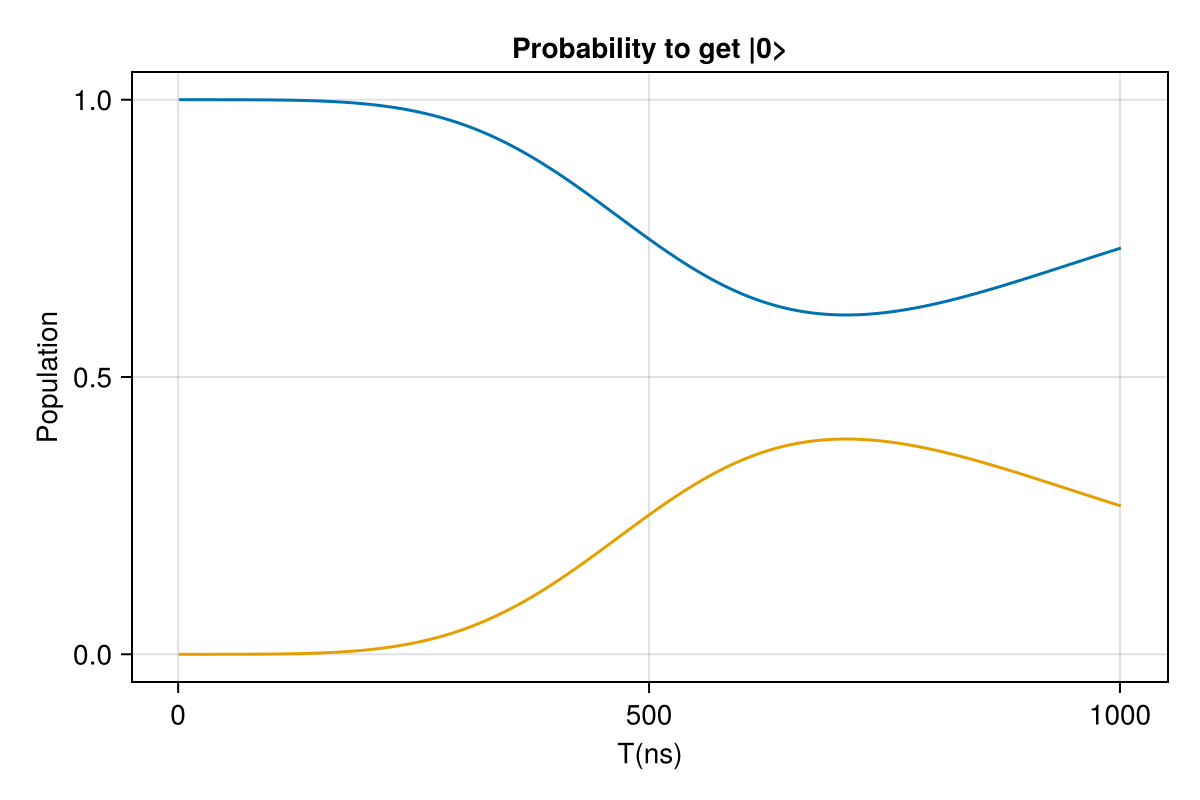

0.2674695843740086

In [ ]:
Tg = 100
T1 = 50
Tϕ = 25
zero_pop = zeros(length(result(Tg).u))
one_pop = zeros(length(result(Tg).u))

for (i,ρ) in enumerate(result(Tg).u)
    zero_pop[i] = ρ[1,1]
    one_pop[i] = ρ[2,2]
end


fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Probability to get |0>", xlabel = "T(ns)", ylabel = "Population")
lines!(ax, zero_pop)
lines!(ax, one_pop)
display(fig)

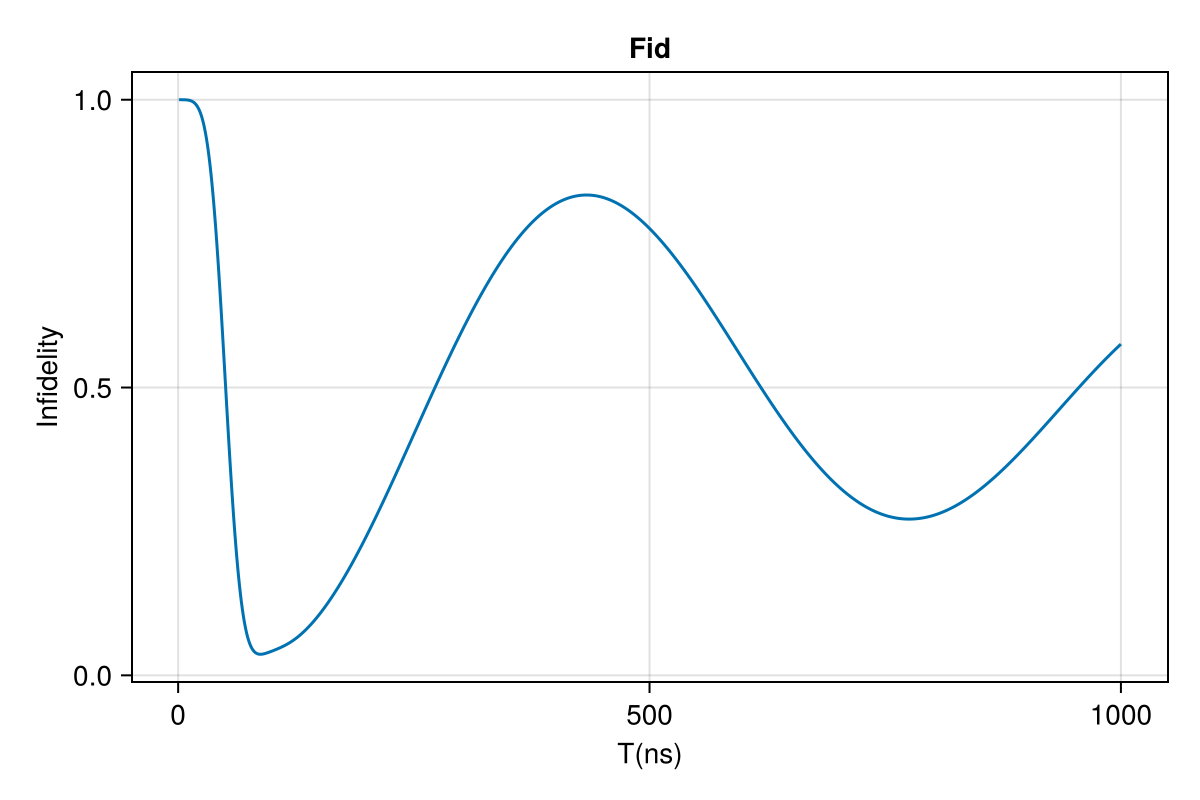

CairoMakie.Screen{IMAGE}


In [89]:

T1 = 150 * 10#^3
Tϕ = 100 * 10#^3
function calc_final_fidelity(Tg)
    return 1 - Uhlmann_Fidelity(target_ρ,result(Tg).u[end])
end

final_fids = []
for i in range(1, 10^3; step = 1)
    push!(final_fids, calc_final_fidelity(i))
end

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Fid", xlabel = "T(ns)", ylabel = "Infidelity")
lines!(ax, final_fids)
display(fig)


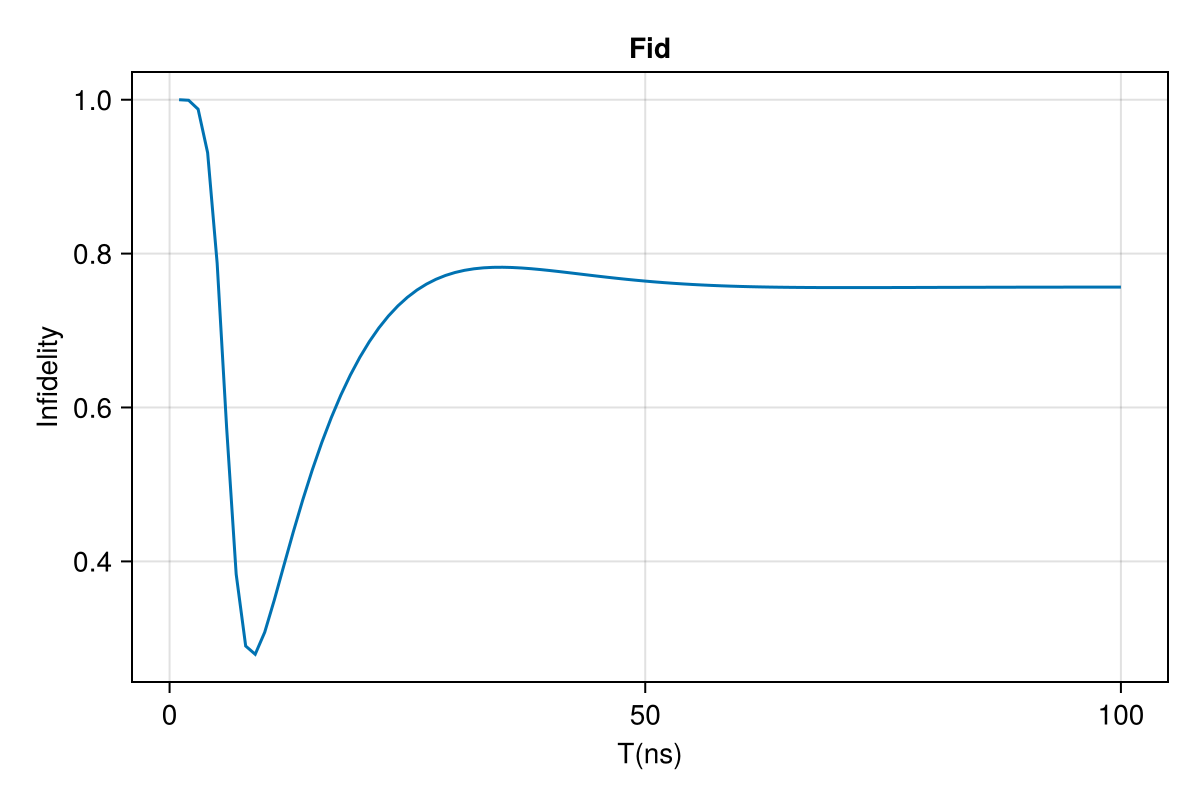

CairoMakie.Screen{IMAGE}


In [94]:
T1 = 150 #* 10#^3
Tϕ = 100 #* 10#^3
final_fids = []
for i in range(1, 1000; step = 10)
    push!(final_fids, calc_final_fidelity(i))
end

fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Fid", xlabel = "T(ns)", ylabel = "Infidelity")
lines!(ax, final_fids)
display(fig)

# Decay

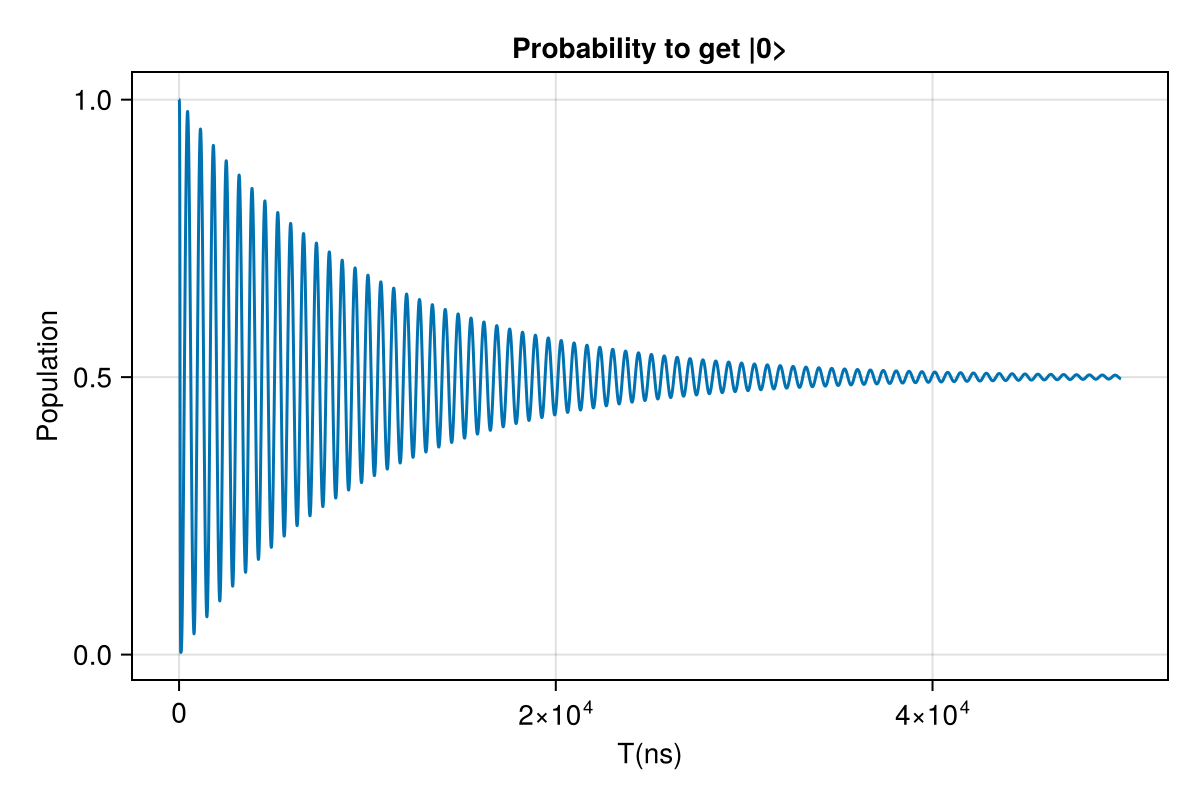

CairoMakie.Screen{IMAGE}


In [14]:
T1 = 150 * 10
Tϕ = 100 * 10 
small_sol = solving(0.5 * 10^4, 1)
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Probability to get |0>", xlabel = "T(ns)", ylabel = "Population")
lines!(ax, small_sol)
display(fig)

## Large Scale

In [65]:
T1 = 150 * 10^3
Tϕ = 100 * 10^3
large_scale = solving(10^6, 1)

1000001-element Vector{Any}:
 1.0
 0.9995058524026542
 0.9891220691274192
 0.9317027936763529
 0.7695090941047444
 0.5000005607201949
 0.23049285936990366
 0.06830305659765853
 0.010890240393229056
 0.0005134198692514306
 ⋮
 0.4999925670978522
 0.49999063086209267
 0.4999887737242947
 0.49998701134508755
 0.49998535858563875
 0.49998382938233804
 0.49998243662928293
 0.4999811920695571
 0.4999801061962177

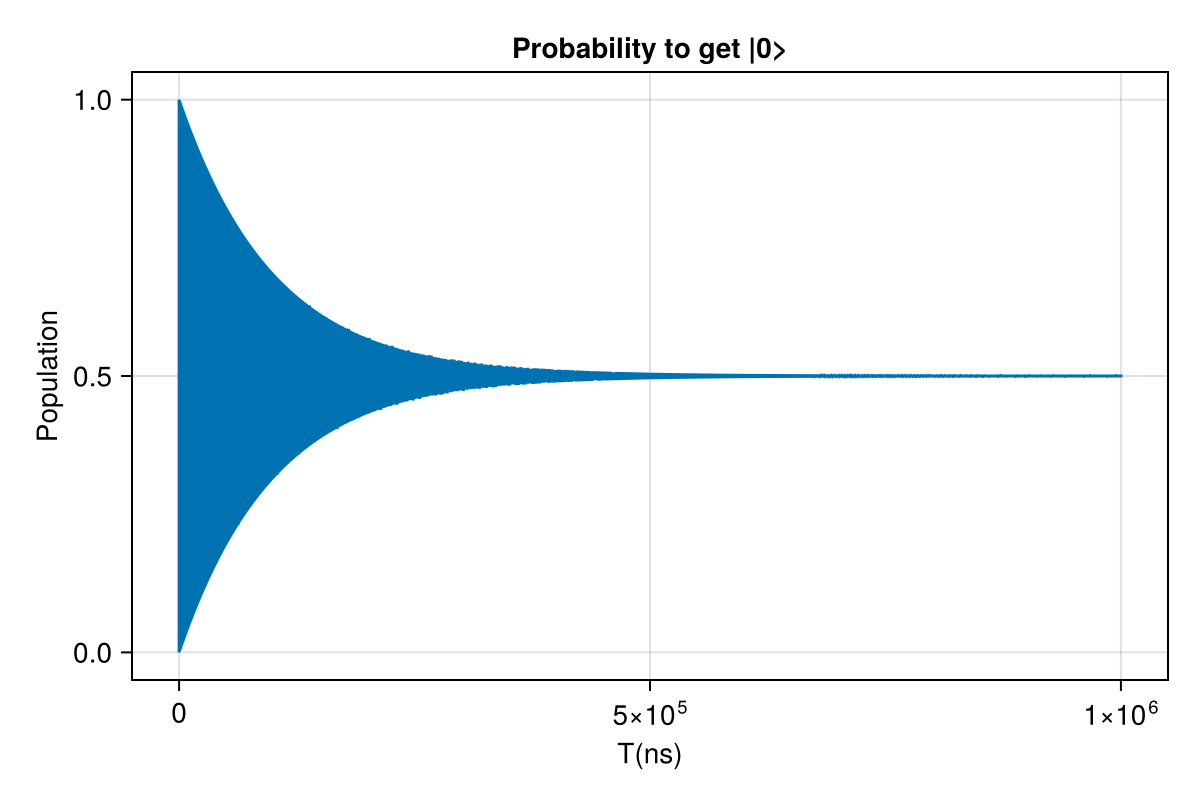

CairoMakie.Screen{IMAGE}


In [66]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Probability to get |0>", xlabel = "T(ns)", ylabel = "Population")
lines!(ax, large_scale)
display(fig)

## Ranging across Tg

In [6]:
infidelities = []
for i in range(1, 50; step = 10)
    Tg = i
    T1 = 150 * 10
    Tϕ = 100 * 10
    time = 10^3
    t_span = (0.0, time)
    prob = ODEProblem(ρ̇!, ρ0,adaptive=false, t_span)
    sol = solve(prob, Tsit5(), dt = 0.1)
    states = sol.u
    push!(infidelities, calc_infidelity(states))
end

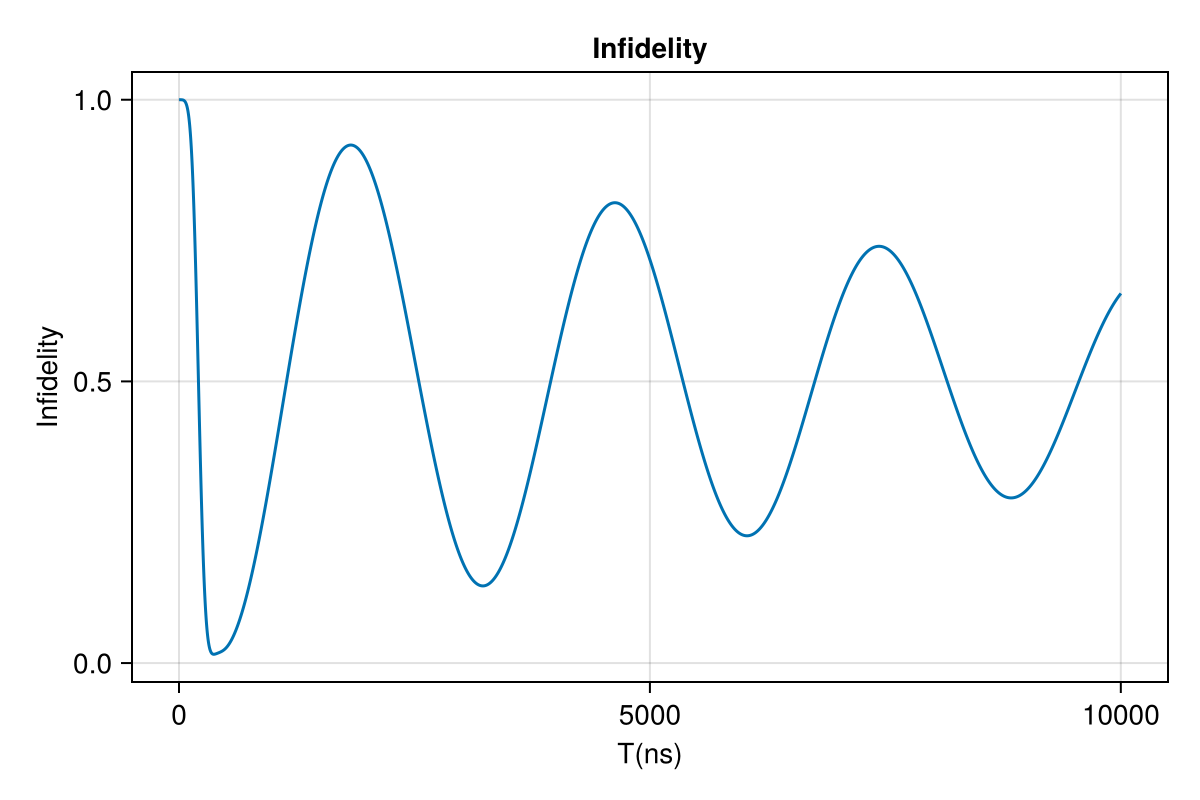

CairoMakie.Screen{IMAGE}


In [8]:
fig = Figure(size = (600, 400))
ax = Axis(fig[1, 1], title = "Infidelity", xlabel = "T(ns)", ylabel = "Infidelity")
lines!(ax, infidelities[5])
display(fig)

In [ ]:
# Tg_range = range(1, 30)
# function solver()
#     states = []
#     for i in Tg_range
#         t_span = (0.0, i)
#         prob = ODEProblem(ρ̇!, ρ0, t_span)
#         sol = solve(prob, Tsit5(), dt=0.05)
#         final = sol.u[end]
#         push!(states, sol.u)
#     end
#     return states
# end


# mega_populations = []
# for i in range(1, size(solver())[1])
#     inner = []
#     for j in range(1, size(solver()[i])[1])
#         push!(inner, real(initial_state' * solver()[i][j] * initial_state))
#     end
#     push!(mega_populations, inner)
# end

# mega_infidelity = []
# for i in range(1, size(solver())[1])
#     inner = []
#     for j in range(1, size(solver()[i])[1])
#         push!(inner, real(Uhlmann_Fidelity(target_ρ, solver()[i][j])))
#     end
#     push!(mega_infidelity, inner)
# end
# #mega_infidelity

In [173]:
# fig = Figure(size = (600, 400))
# ax = Axis(fig[1, 1], title = "Probability to get |0> along the solved path", xlabel = "T(ns)", ylabel = "Population")
# for i in range(1, size(mega_populations)[1])
#     lines!(ax, mega_populations[i])
# end
# display(fig)

In [174]:
# fig = Figure(size = (600, 400))
# ax = Axis(fig[1, 1], title = "Probability to get |0> along the solved path", xlabel = "T(ns)", ylabel = "Population")
# for i in range(1, size(mega_infidelity)[1])
#     lines!(ax, mega_infidelity[i])
# end
# display(fig)